In [1]:
# %matplotlib ipympl
%matplotlib inline

In [2]:
import nilmtk
from nilmtk.timeframe import TimeFrame

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
TRAINING_DATA_DURATION = 12
delta_time = pd.to_timedelta(TRAINING_DATA_DURATION, unit='h')

In [5]:
ukdale_2015 = nilmtk.DataSet("ukdale_2015.h5")

In [6]:
ukdale_2015.buildings

OrderedDict([(1, Building(instance=1, dataset='UK-DALE')),
             (2, Building(instance=2, dataset='UK-DALE')),
             (3, Building(instance=3, dataset='UK-DALE')),
             (4, Building(instance=4, dataset='UK-DALE')),
             (5, Building(instance=5, dataset='UK-DALE'))])

# Building 1

In [7]:
building_1 = ukdale_2015.buildings[1].elec

In [8]:
building_1.mains()

ElecMeter(instance=54, building=1, dataset='UK-DALE', site_meter, appliances=[Appliance(type='immersion heater', instance=1), Appliance(type='water pump', instance=1), Appliance(type='security alarm', instance=1), Appliance(type='fan', instance=2), Appliance(type='drill', instance=1), Appliance(type='laptop computer', instance=2)])

In [9]:
building_1.submeters()

MeterGroup(meters=
  ElecMeter(instance=2, building=1, dataset='UK-DALE', appliances=[Appliance(type='boiler', instance=1)])
  ElecMeter(instance=3, building=1, dataset='UK-DALE', appliances=[Appliance(type='solar thermal pumping station', instance=1)])
  ElecMeter(instance=4, building=1, dataset='UK-DALE', appliances=[Appliance(type='laptop computer', instance=1), Appliance(type='laptop computer', instance=3)])
  ElecMeter(instance=5, building=1, dataset='UK-DALE', appliances=[Appliance(type='washer dryer', instance=1)])
  ElecMeter(instance=6, building=1, dataset='UK-DALE', appliances=[Appliance(type='dish washer', instance=1)])
  ElecMeter(instance=7, building=1, dataset='UK-DALE', appliances=[Appliance(type='television', instance=1)])
  ElecMeter(instance=8, building=1, dataset='UK-DALE', appliances=[Appliance(type='light', instance=1), Appliance(type='light', instance=2)])
  ElecMeter(instance=9, building=1, dataset='UK-DALE', appliances=[Appliance(type='HTPC', instance=1)])
  Ele

## Main meter

In [10]:
building_1.mains()

ElecMeter(instance=54, building=1, dataset='UK-DALE', site_meter, appliances=[Appliance(type='immersion heater', instance=1), Appliance(type='water pump', instance=1), Appliance(type='security alarm', instance=1), Appliance(type='fan', instance=2), Appliance(type='drill', instance=1), Appliance(type='laptop computer', instance=2)])

In [11]:
main_meter = building_1.mains()

In [12]:
start_time = main_meter.get_timeframe().start
end_time = start_time + delta_time

In [13]:
print("Start Time:", start_time)
print("End Time:",   end_time)

Start Time: 2013-03-17 19:12:43.100000+00:00
End Time: 2013-03-18 07:12:43.100000+00:00


In [14]:
kw = {'sections': [TimeFrame(start=start_time, end=end_time)], 'sample_period': 6, 'resample': True}

In [15]:
main_df = main_meter.power_series_all_data(**kw)

In [16]:
main_df = main_df.to_frame().fillna(0)

<Axes: >

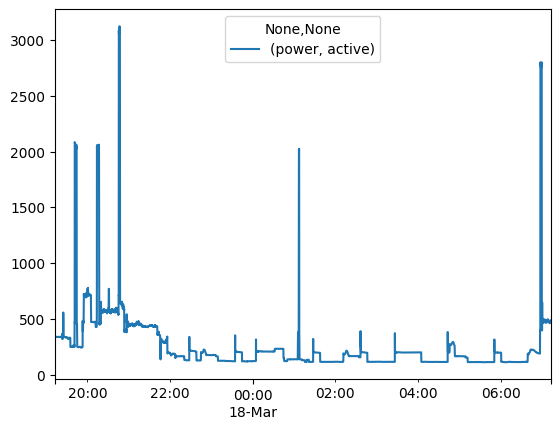

In [17]:
main_df.plot()

## Fridge

In [18]:
fridge = building_1['fridge']
fridge_df = fridge.power_series_all_data(**kw)

In [19]:
fridge_df = fridge_df.to_frame().fillna(0)

<Axes: >

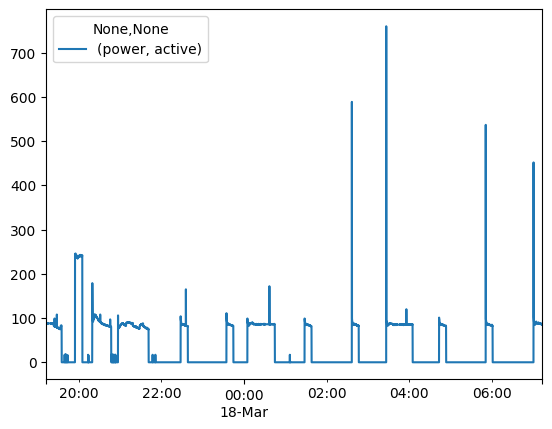

In [20]:
fridge_df.plot()

## Microwave

In [21]:
microwave = building_1['microwave']
microwave_df = microwave.power_series_all_data(**kw)

In [22]:
microwave_df = microwave_df.to_frame().fillna(0)

<Axes: >

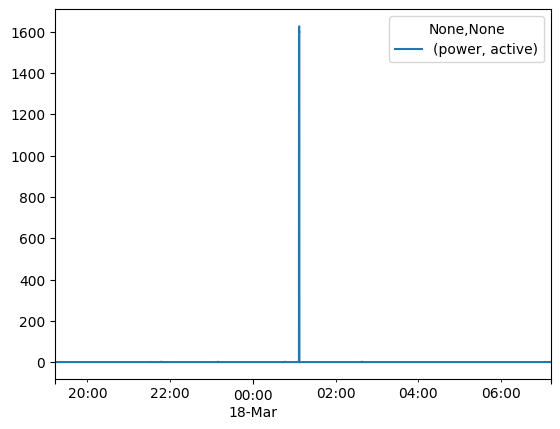

In [23]:
microwave_df.plot()

## Hart85

In [24]:
# Hart85 functions
from nilmtk.disaggregate.hart_85 import Hart85

from nilmtk.feature_detectors.steady_states import find_steady_states
from nilmtk.feature_detectors.cluster import hart85_means_shift_cluster

In [25]:
# Initiate the Hart85 model
m_hart = Hart85({})

In [26]:
# Global variables
noise_level = 70
state_threshold = 15

In [27]:
columns = pd.MultiIndex.from_tuples([('power', 'apparent')])

### Step 1: Find steady states

In [28]:
m_hart.columns = columns
m_hart.steady_states, m_hart.transients = find_steady_states(main_df,  
                                                             noise_level = noise_level, 
                                                             state_threshold = state_threshold)  

Finding Edges, please wait ...
Edge detection complete.
Creating transition frame ...
Transition frame created.
Creating states frame ...
States frame created.
Finished.


Text(0.5, 0, 'Time')

<Figure size 1000x700 with 0 Axes>

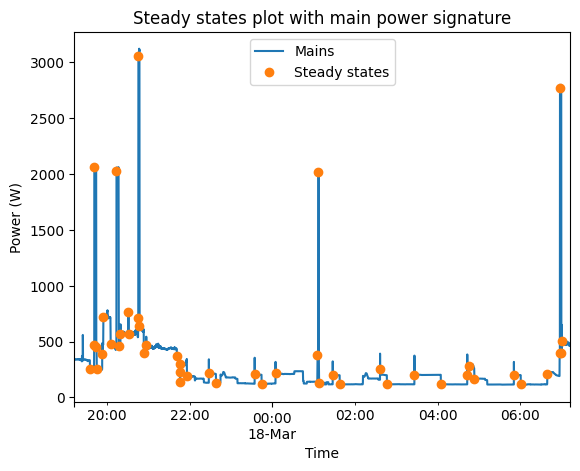

In [29]:
# Plot steady states with main
fig = plt.figure(figsize=(10, 7))
ax = main_df.plot()
m_hart.steady_states.plot(style='o', ax = ax);

plt.title("Steady states plot with main power signature")
plt.legend(["Mains", "Steady states"]);
plt.ylabel("Power (W)")
plt.xlabel("Time")

### Step 2: Find pairs (Rising Edge and Falling Edge)

In [30]:
# Parameters for pairing function
buffer_size = 20
min_tolerance = 100
percent_tolerance = 0.035
large_transition = 1000

In [31]:
m_hart.pair_df = m_hart.pair(buffer_size, min_tolerance, percent_tolerance, large_transition)

.........................Hart_85 Partial Fit End....................


In [32]:
m_hart.pair_df

,T1 Time,T1 Apparent,T2 Time,T2 Apparent
0,2013-03-17 19:41:36+00:00,1591.372549,2013-03-17 19:44:24+00:00,-1576.311536
1,2013-03-17 19:41:18+00:00,201.564845,2013-03-17 19:45:00+00:00,-204.524103
2,2013-03-17 19:54:36+00:00,244.412508,2013-03-17 20:05:06+00:00,-242.928265
3,2013-03-17 20:13:42+00:00,1591.055213,2013-03-17 20:16:54+00:00,-1585.973610
4,2013-03-17 20:30:48+00:00,195.068820,2013-03-17 20:31:24+00:00,-195.219703
5,2013-03-17 20:45:12+00:00,165.184274,2013-03-17 20:53:24+00:00,-201.994535
6,2013-03-17 20:56:54+00:00,74.316948,2013-03-17 21:41:24+00:00,-70.943859
7,2013-03-17 20:19:36+00:00,100.731777,2013-03-17 21:45:36+00:00,-125.975881
8,2013-03-17 19:53:06+00:00,141.890600,2013-03-17 21:45:54+00:00,-87.889999
9,2013-03-17 21:46:18+00:00,155.815452,2013-03-17 21:56:00+00:00,-128.833773


In [33]:
# Compute avg of paired transitions using the formula (as in pair_transitions function in pairing module)
pair_shape_df = pd.DataFrame(columns=['Height (W)','Duration (s)'])

pair_shape_df['Height (W)']= (m_hart.pair_df['T1 Apparent'].abs() + m_hart.pair_df['T2 Apparent'].abs()) / 2
pair_shape_df['Duration (s)']= pd.to_timedelta(m_hart.pair_df['T2 Time'] - m_hart.pair_df['T1 Time'],unit='s').dt.seconds

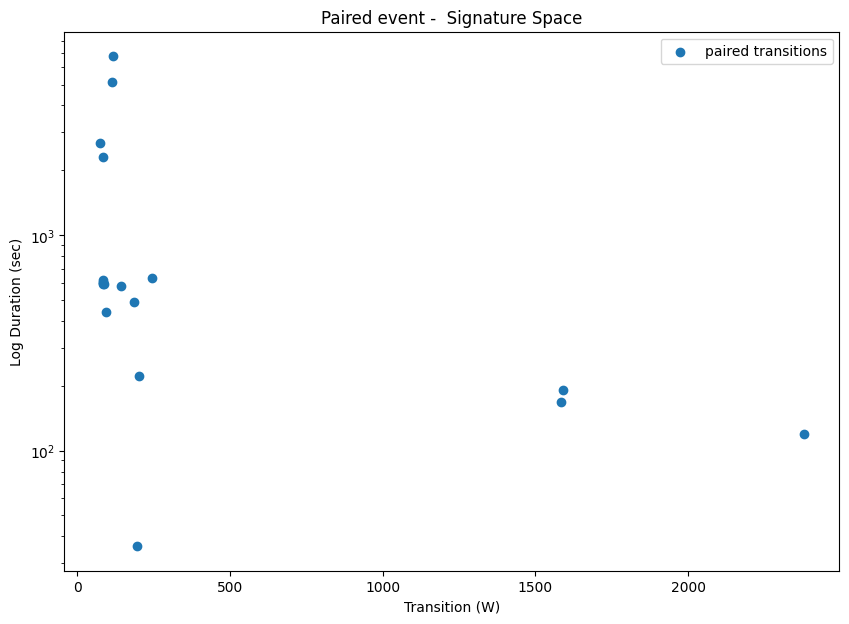

In [34]:
# Plot paired event space
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(1, 1, 1)

# Time in log scale
ax.set_yscale('log')

# Plot paired transitions
ax.scatter(pair_shape_df['Height (W)'], pair_shape_df['Duration (s)'], label='paired transitions')

plt.title("Paired event -  Signature Space")
plt.legend()
plt.ylabel("Log Duration (sec)")
plt.xlabel("Transition (W)");

### Step 3: Find Clusters

In [35]:
m_hart.centroids = hart85_means_shift_cluster(m_hart.pair_df, m_hart.columns)

In [36]:
m_hart.centroids

,power
,apparent
0,124.271931
1,1586.178227
2,2380.196553


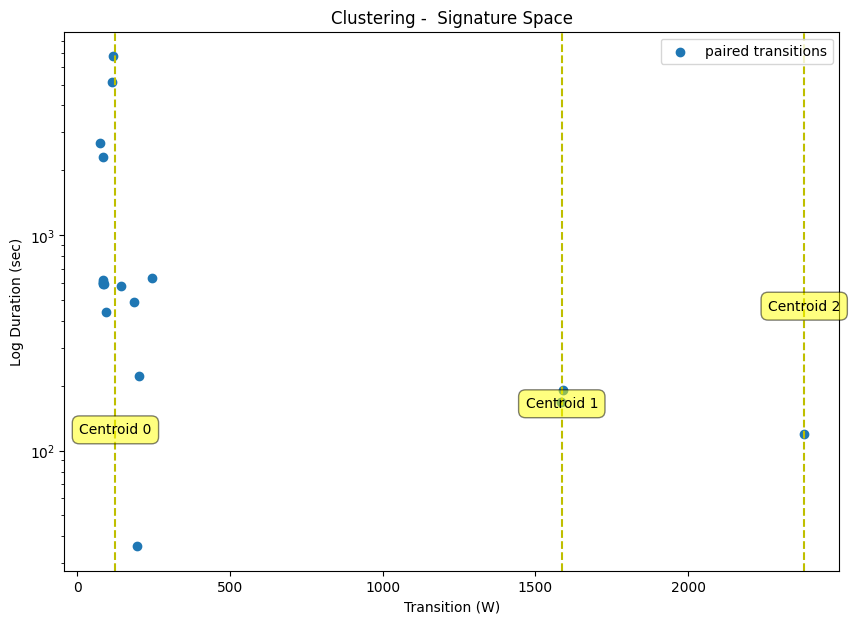

In [37]:
# Plot centroids
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1)

# Time in log scale
ax.set_yscale('log')

# Plot paired transitions
ax.scatter(pair_shape_df['Height (W)'], pair_shape_df['Duration (s)'], label='paired transitions')

# Lines for centroids
for i, row in m_hart.centroids.iterrows():
    ax.axvline(m_hart.centroids.iloc[i, 0],color = 'y', linestyle='--')

plt.legend(loc=1)
plt.title("Clustering -  Signature Space")
plt.ylabel("Log Duration (sec)")
plt.xlabel("Transition (W)");

# Adding annotation for centroids
labels = ['Centroid {0}'.format(i) for i in range(len(m_hart.centroids))]
for label, x, y in zip(labels, m_hart.centroids[('power','apparent')], pair_shape_df['Duration (s)']):
    plt.annotate(
        label, 
        xy = (x, y), xytext = (0, -20),
        textcoords = 'offset points', ha = 'center', va = 'center',
        bbox = dict(boxstyle = 'round,pad=0.5', fc = 'yellow', alpha = 0.5))